In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import patches
from matplotlib import colors
from IPython.display import HTML
from tqdm.notebook import tqdm

from glob import glob
import pickle
from sklearn.preprocessing import QuantileTransformer
from astropy.visualization import simple_norm

In [2]:
# naive rolling median window in time
# this might not be efficient
def build_static(cube, window=50):
    nt, nx, ny = cube.shape
    df = pd.DataFrame(cube.reshape(nt, nx*ny))
    rmed = df.rolling(window, min_periods=10, center=True, closed="both").median().values.reshape(nt, nx, ny)
    # silly solution of repeating the first 50 frames to match the shape
    # this needs to be better, maybe interpolation?
    # med = np.median(cube[:window], axis=0)
    # rmed[:window-1] = np.repeat(med.reshape(-1, nx, ny), window-1, axis=0)
    return rmed

In [3]:
def plot_img_aperture(col, row, img, aperture_mask, 
                      ax=None, nt=0, cbar=False):

    if ax is None:
        fig, ax = plt.subplots()
        fig.suptitle(f"Asteroid Tracks in Sector {sector} Camera {camera} CCD {ccd}")
    im = ax.pcolormesh(
        col, row,
        img, 
        cmap="Greys_r",
        vmin=lo, 
        vmax=vhi,
        # norm=norm,
        rasterized=True
    )
    ax.set_aspect('equal', "box")
    ax.set_title(f"CAD {cadno[nt]} | BTJD {time[nt] - 2457000:.4f}")
    if cbar:
        plt.colorbar(im, location="right", shrink=.8, label="Flux [-e/s]")
    
    # for i, pi in enumerate(row[:, 0]):
    #     for j, pj in enumerate(col[0, :]):
    #         if aperture_mask[i, j]:
    #             # print("here")
    #             rect = patches.Rectangle(
    #                 xy=(pj - 0.5, pi - 0.5),
    #                 width=1,
    #                 height=1,
    #                 color="tab:red",
    #                 fill=False,
    #                 alpha=0.4,
    #             )
    #             ax.add_patch(rect)

    ax.set_xlabel("Pixel Column")
    ax.set_ylabel("Pixel Row")

    return ax

def animate_image(col, row, cube, aperture_mask, 
                  interval=200, repeat_delay=1000):

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"Asteroid Tracks in Sector {sector} Camera {camera} CCD {ccd}")

    ax = plot_img_aperture(col, row, cube[0], aperture_mask[0], 
                           ax=ax, cbar=True)

    def animate(nt):
        ax.clear()
        _ = plot_img_aperture(col, row, cube[nt], aperture_mask[nt], 
                              ax=ax, nt=nt, cbar=False)
        
        return ()

    plt.close(ax.figure)

    # Create the animation
    ani = animation.FuncAnimation(
        fig, animate, frames=len(cube), interval=interval, blit=True, repeat_delay=repeat_delay, repeat=True,
    )

    return ani

In [4]:
sector = 6
camera = 1
ccd = 4
norb = 1

local = "/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts"
adapt = "/explore/nobackup/projects/asteroid/data/asteroidcuts"

forb = [sorted(glob(
    f"{local}/sector{sector:04}/tess-asteroid-cuts_*_s{sector:04}-{camera}-{ccd}*orb{k}_*.npz"
)) for k in range(norb,norb+1)]
forb = np.asarray([x for x in forb if x != []]).T
forb.shape

(6, 1)

In [5]:
rnd_fc = np.random.randint(0, 34, size=15)
rnd_nc = np.random.randint(0, 34, size=15)

In [6]:
forb

array([['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_1054.npz'],
       ['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_1354.npz'],
       ['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_1834.npz'],
       ['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_454.npz'],
       ['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_694.npz'],
       ['/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_814.npz']],
      dtype='<U131')

In [42]:
data = np.load(forb[0, 0])
data

NpzFile '/Users/jimartin/Work/TESS/tess-asteroid-ml/data/asteroidcuts/sector0006/tess-asteroid-cuts_64x64_s0006-1-4_V20.0_orb1_bkgF_1054.npz' with keys: flux, column, row, mask, time...

0
2


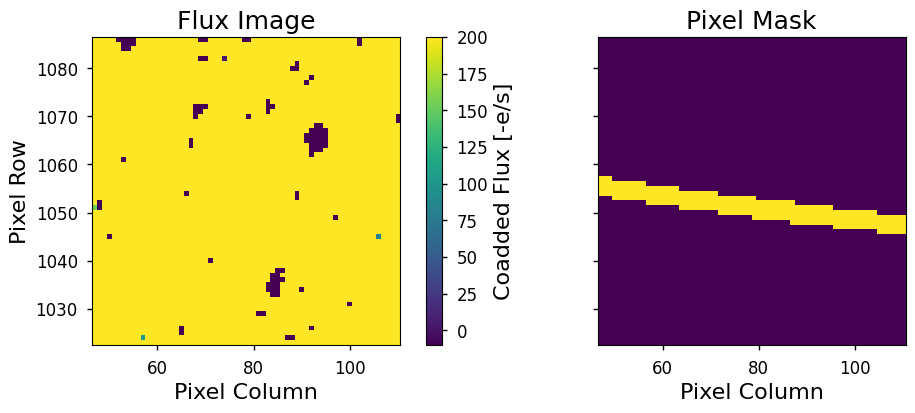

1
2


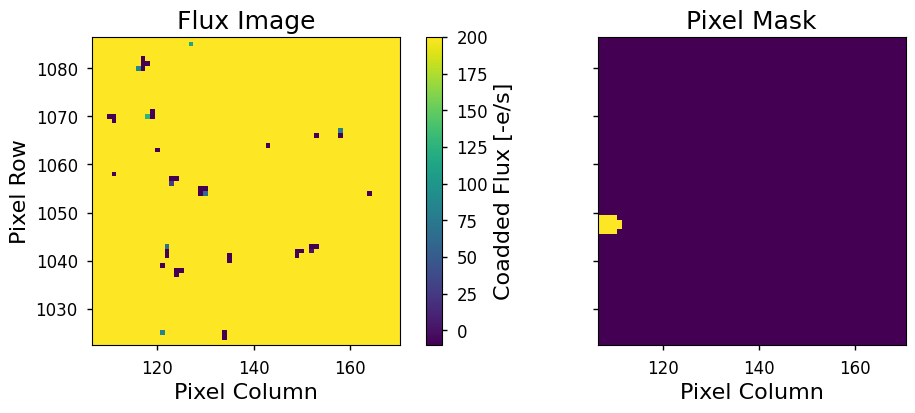

2
3
4
5
2


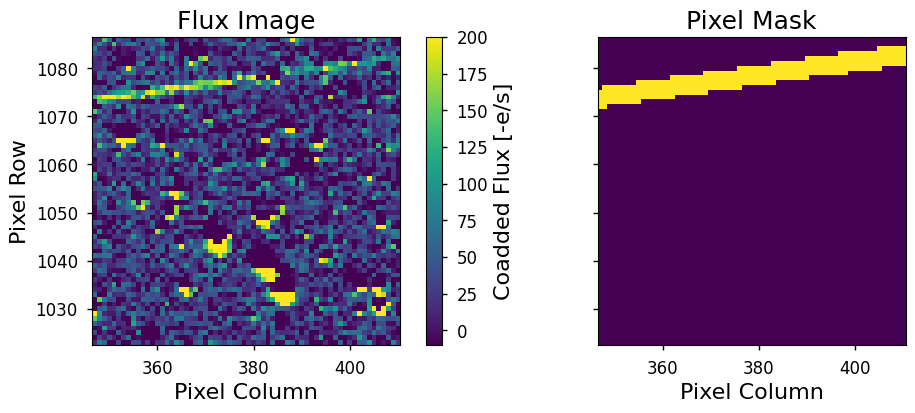

6
2


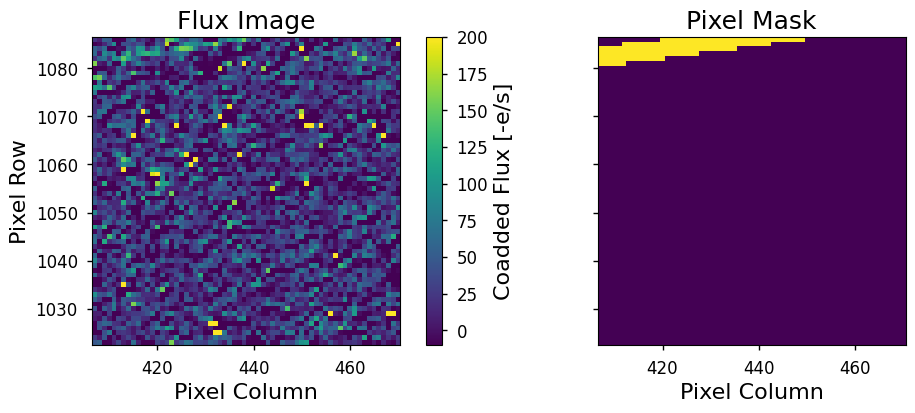

7
8
9
2


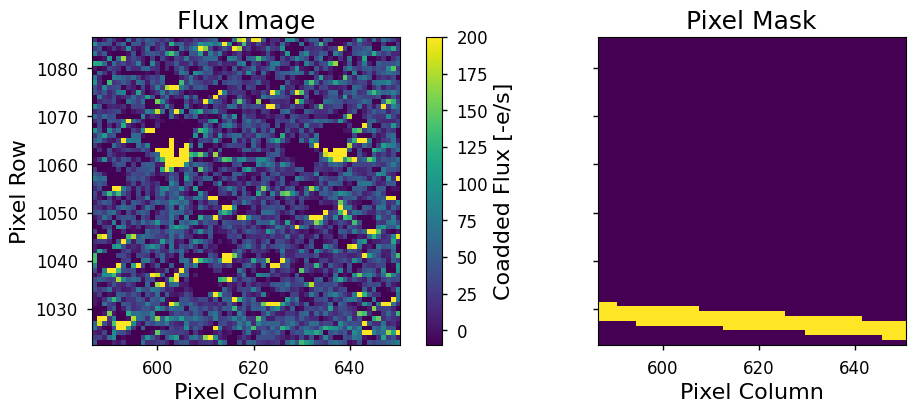

10
2


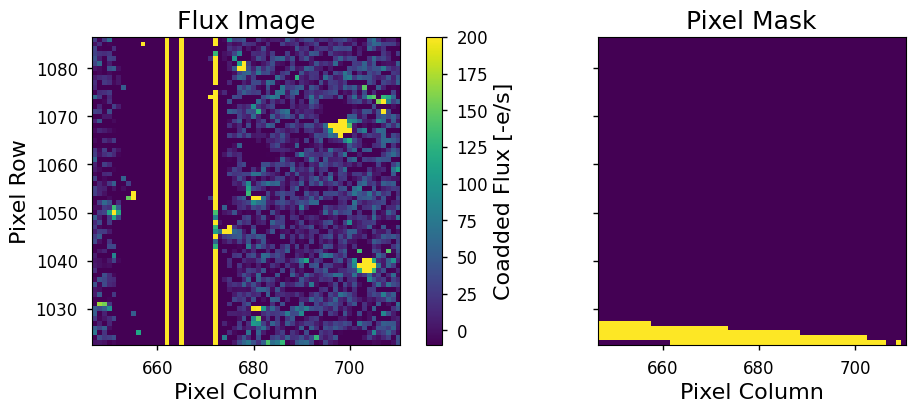

11
2


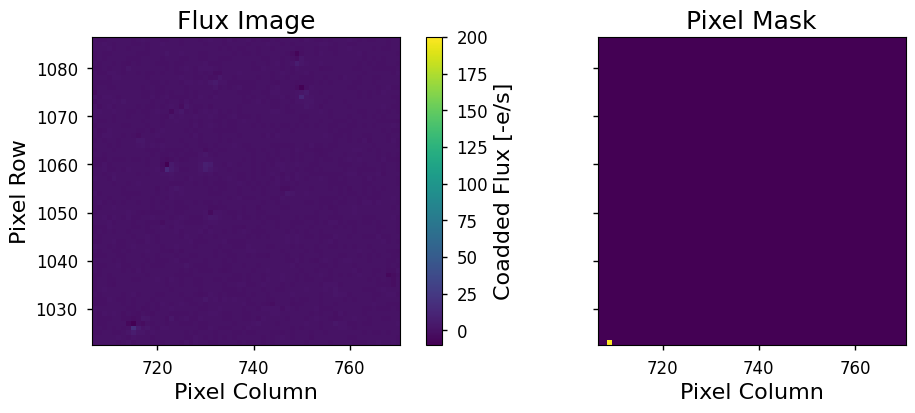

12
13
14
2


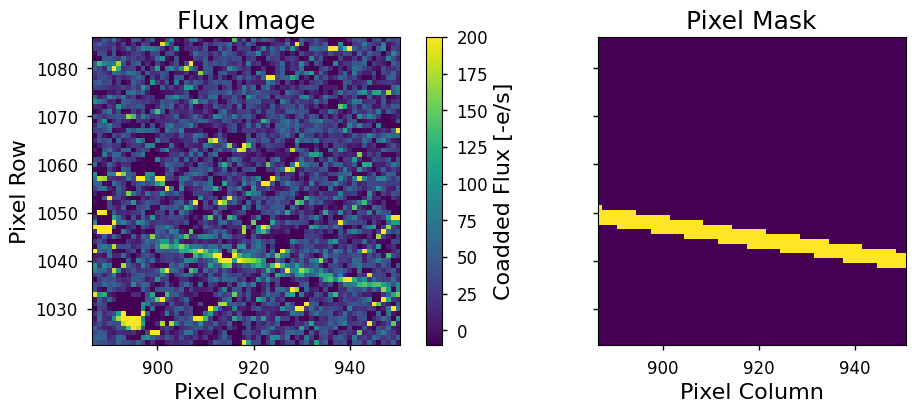

15
16
2


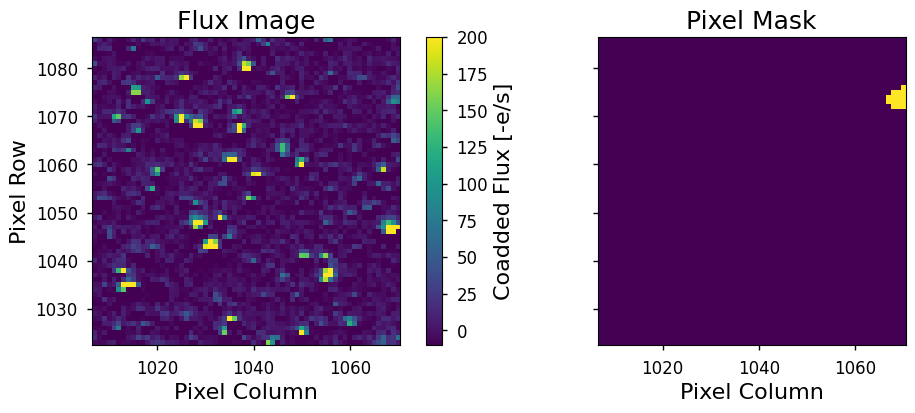

17
2


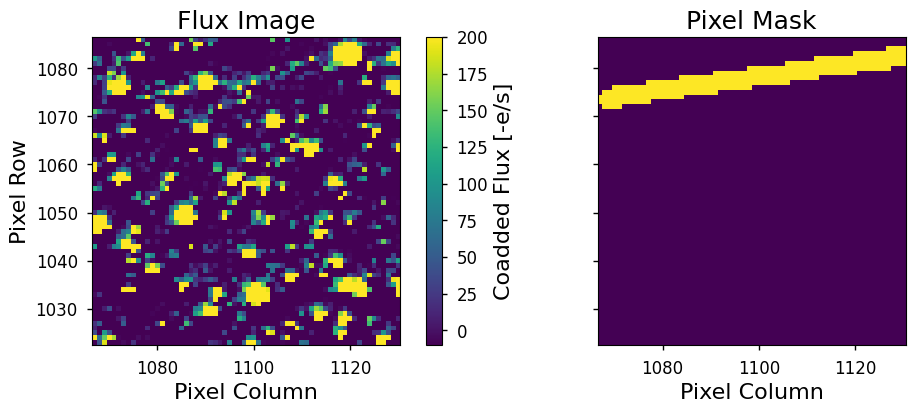

18
2


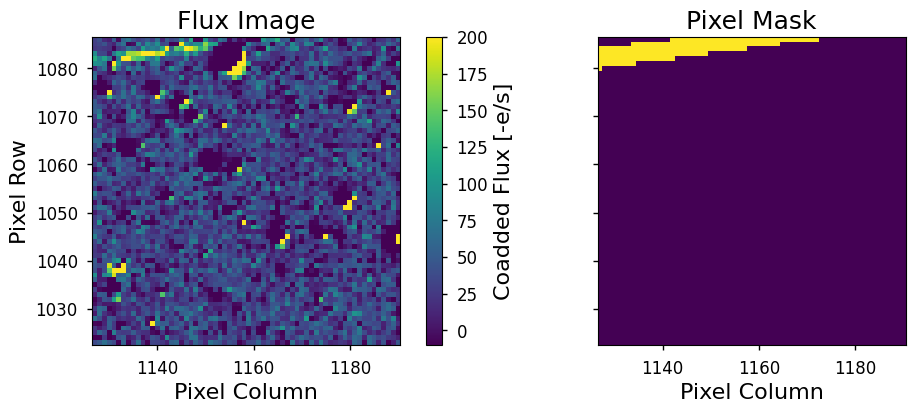

19
2


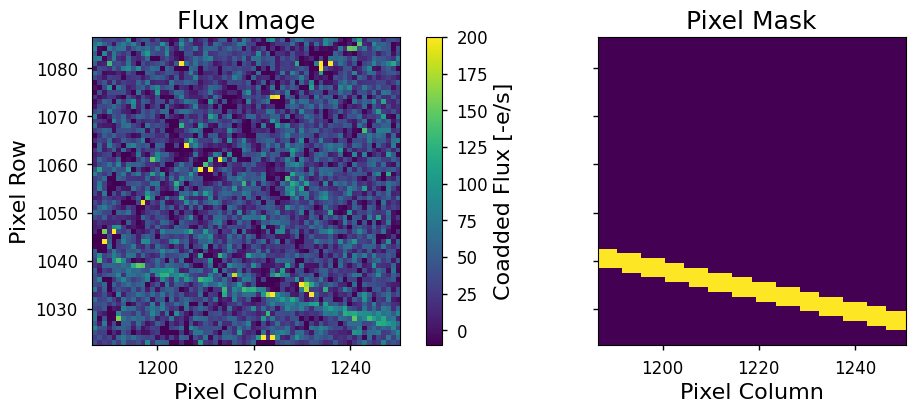

20
21
22
23
24
25
26
2


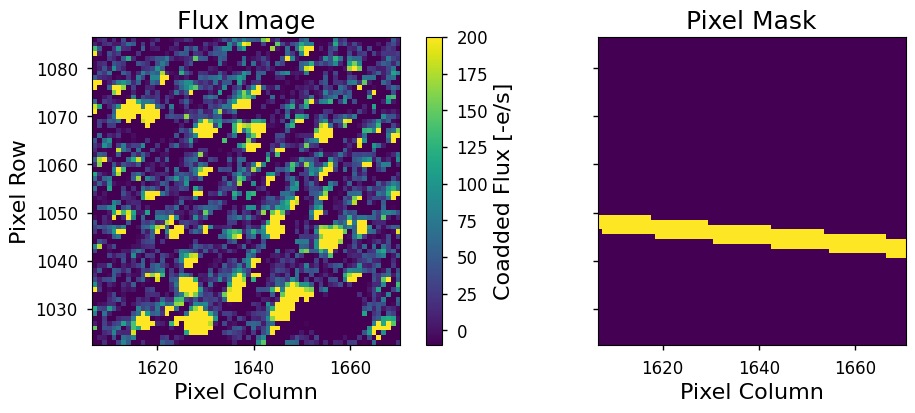

27
2


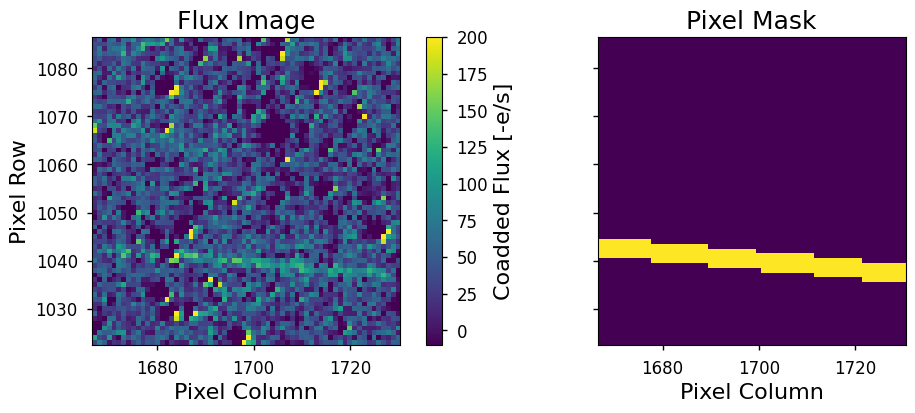

28
2


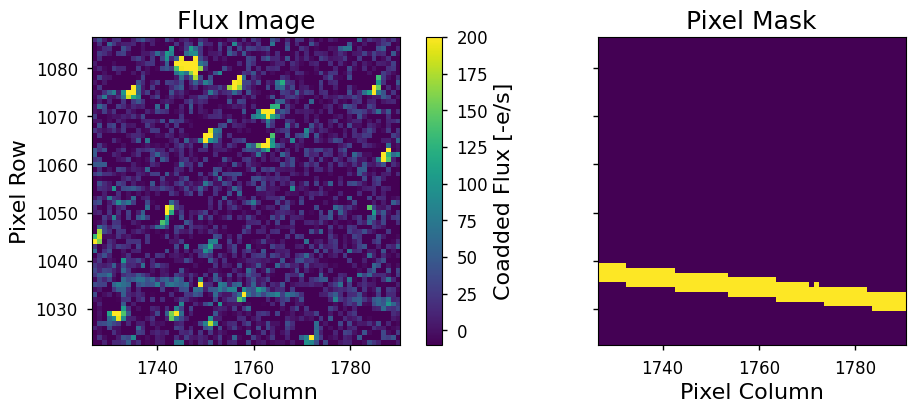

29
2


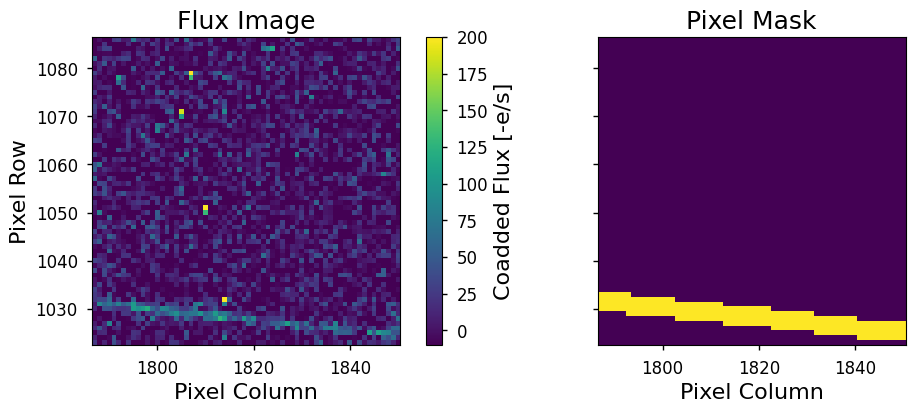

30
31
32
33


In [50]:
with plt.style.context("seaborn-v0_8-notebook"):
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 18
    for cdx in range(34):
        print(cdx)
        cube_flux = data["flux"][cdx]
        diff = cube_flux - build_static(cube_flux, window=99)
        row = data["row"][cdx]
        col = data["column"][cdx]
        row, col = np.mgrid[row:row+64, col:col+64]
        for s in np.unique(data["mask"][cdx])[1:]:
            if s not in [2]: continue
            print(s)
            times = np.where(data["mask"][cdx] == s)[0]
            fig, ax = plt.subplots(1,2, figsize=(12,4), sharex=True, sharey=True, width_ratios=[1.6, 1], squeeze=True)
            cbar = ax[0].pcolormesh(
                col, row,
                diff[times].sum(axis=0), 
                vmin=-10, vmax=200
            )
            plt.colorbar(cbar, ax=ax[0], label="Coadded Flux [-e/s]")
            
            ax[1].pcolormesh(
                col, row,
                (data["mask"][cdx] == s).sum(axis=0), 
                vmin=0, vmax=1
            )
    
            ax[0].set_title("Flux Image")
            ax[1].set_title("Pixel Mask")
            ax[0].set_ylabel("Pixel Row")
            ax[0].set_xlabel("Pixel Column")
            ax[1].set_xlabel("Pixel Column")
            ax[0].set_aspect("equal")
            ax[1].set_aspect("equal")
            plt.show()
        # break

In [10]:
for nf in tqdm(rnd_fc, total=15):
    
    mask = []
    flux = []
    col = []
    row = []
    time = []
    cadno = []
    
    for f in forb[nf][:1]:
        data = np.load(f)
        
        mask.append(data["mask"].transpose(1,0,2,3))
        flux.append(data["flux"].transpose(1,0,2,3))
        col = data["column"]
        row = data["row"]
        time.extend(data["time"])
        cadno.extend(data["cadenceno"])
    
    mask = np.vstack(mask).transpose(1,0,2,3)
    flux = np.vstack(flux).transpose(1,0,2,3)
    
    time = np.array(time)
    cadno = np.array(cadno)
    
    for nc in rnd_nc: 
    
        cube_flux = flux[nc]
        cube_mask = mask[nc]
        
        cube_row2d, cube_col2d = np.mgrid[row[nc] : row[nc] + 64, col[nc] : col[nc] + 64]
        
        # diff = cube_flux - np.nanmedian(cube_flux, axis=0)
        diff = cube_flux - build_static(cube_flux, window=99)
        vlo, lo, mid, hi, vhi = np.nanpercentile(diff, [1, 5, 50, 95, 99.8])
        
        # norm = simple_norm(diff.ravel(), 'asinh', min_percent=20, max_percent=95)
        
        # cube_flux.shape, cube_mask.shape, cube_row2d.shape, cube_col2d.shape
        
        # save animation to movie file
        # animate_image(
        #     cube_col2d, cube_row2d, cube_mask, cube_mask, interval=75
        # ).save(f"./figures/sector{sector:04}/cutout_training_{camera}-{ccd}_animation_{nf}-{nc}-{norb}.gif", writer="pillow")

        # cube_flux_rescaled = QuantileTransformer().fit_transform(cube_flux.flatten().reshape(-1, 1)).reshape(cube_flux.shape)
        # diff = cube_flux_rescaled - build_static(cube_flux_rescaled, window=99)
        # norm = simple_norm(diff.ravel(), 'asinh', min_percent=20, max_percent=95)

        HTML(
        animate_image(
                cube_col2d, cube_row2d, diff, cube_mask, interval=75
            ).to_jshtml()
            #.save(f"./figures/sector{sector:04}/cutout_training_{camera}-{ccd}_animation_{nf}-{nc}-{norb}_rescaled.gif", writer="pillow")
        )
        
        break
    break

  0%|          | 0/15 [00:00<?, ?it/s]

Animation size has reached 21023672 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


((342, 64, 64), (342, 64, 64), (64, 64), (64, 64))